# HyDE (Hypothetical Document Embedding) 실험

HyDE(Hypothetical Document Embeddings)는 **사용자 질문에 대해 LLM(대형 언어 모델)로 가상의 문서를 먼저 생성하고, 이 문서를 임베딩하여 검색하는 방식**이다.  
기존에는 질문 자체를 임베딩해 유사한 문서를 찾았지만, HyDE는 질문의 맥락과 의도를 더 잘 반영할 수 있는 가상 문서를 생성해 임베딩하고, 이를 벡터 DB에서 비교함으로써 **더 정확한 검색 결과**를 얻을 수 있다.

**핵심 요약**
- 질문 → LLM이 가상 문서 생성 → 임베딩 → 벡터 DB에서 유사도 검색
- 기존 방식보다 **질문의 의미와 맥락을 더 잘 반영**하여 검색 정확도 향상
- RAG 등 다양한 검색·생성 AI 시스템에서 활용 가능
- 단점: LLM 사용으로 **속도가 느려질 수 있음**

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['PINECONE_API_KEY'] = os.getenv('PINECONE_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

In [3]:
import pandas as pd
from kiwipiepy import Kiwi # Kiwi 형태소 분석기

kiwi = Kiwi()

document_df = pd.read_csv('documents.csv')
queries_df = pd.read_csv('queries.csv')


In [4]:
# BM25 키워드 검색 모델
# - 문서를 토큰화해서 BM25 모델 생성
# - 검색어도 동일하게 토큰화하여 BM25 검색시 활용

from rank_bm25 import BM25Okapi
from kiwipiepy import Kiwi

# Kiwi로 문장을 형태소 단위로 토큰화하는 함수
def kiwi_tokenize(doc):
    return [token.form for token in kiwi.tokenize(doc)]

# 문서 내용 토큰화
tokenized_docs = [kiwi_tokenize(doc) for doc in document_df['content']]
bm25 = BM25Okapi(tokenized_docs) # BM25 모델 생성 (토큰화된 문서)

# 질의문을 토큰화해서 BM25로 상위 문서 검색하는 함수
def bm25_search(query, top_k =5):
    query_tokens = kiwi_tokenize(query)         # 검색어 토큰화
    scores = bm25.get_scores(query_tokens)    # 각 문서의 BM25 점수 계산  

    # 점수 기준 내림차순 정렬한 인덱스
    ranked_idx = sorted(range(len(scores)), key = lambda i: scores[i], reverse= True)
    # 상위 top_k개의 doc_id 리스트
    retrieved_docs = [document_df['doc_id'].iloc[i] for i in ranked_idx[:top_k]]
    return retrieved_docs

bm25_search('제주도 관광 명소')

['D1', 'D2', 'D3', 'D4', 'D5']

In [5]:
from langchain_openai import OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

# 1536차원 임베딩 모델
embeddings = OpenAIEmbeddings(model = 'text-embedding-3-small') 

 # 벡터스토어 연결
vector_store = PineconeVectorStore(
    index_name = 'ir',      # 연결할 index명
    embedding=embeddings,   # 사용할 임베딩 함수 (연결할 인덱스 차원과 임베딩차원이 같아야 함)
)

### Hyde 가상문서(가설 답변) 생성 체인 구성

In [6]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

llm = init_chat_model('gpt-5.6-luna', temperature=0.3)
prompt = PromptTemplate.from_template('''
질문 : {query}

위 질문에 대해서 실제 문서가 아니어도 좋으니, 답변을 생성해주세요.
''')

output_parser = StrOutputParser()

hyde_chain = prompt | llm | output_parser
print(hyde_chain.invoke('제주도 관광 명소'))

제주도에는 자연경관과 문화유적을 함께 즐길 수 있는 관광 명소가 많습니다.

### 대표 관광 명소

1. **한라산 국립공원**
   - 제주도의 중심에 있는 대한민국 최고봉
   - 성판악·관음사 코스 등 등산로가 있으며, 계절마다 풍경이 다릅니다.

2. **성산일출봉**
   - 유네스코 세계자연유산으로 지정된 대표 명소
   - 정상에서 보는 일출과 제주 동부 해안 풍경이 아름답습니다.

3. **우도**
   - 배를 타고 방문할 수 있는 작은 섬
   - 서빈백사, 검멀레해변, 우도봉 등이 유명하며 전기자전거 여행도 인기가 많습니다.

4. **협재해수욕장**
   - 맑고 푸른 바다와 하얀 모래사장이 아름다운 해변
   - 비양도를 바라볼 수 있으며 카페와 맛집도 많습니다.

5. **함덕해수욕장**
   - 수심이 비교적 얕고 바닷물이 맑아 가족 여행지로 좋습니다.
   - 해변 주변 산책로와 카페가 잘 조성되어 있습니다.

6. **만장굴**
   - 세계적으로 유명한 용암동굴
   - 제주도의 화산 활동으로 형성된 독특한 지형을 볼 수 있습니다.

7. **주상절리대**
   - 바닷가 절벽에 육각형 기둥 모양의 암석이 펼쳐진 명소
   - 중문 관광단지와 가까워 함께 둘러보기 좋습니다.

8. **천지연폭포·정방폭포**
   - 제주도의 대표적인 폭포 관광지입니다.
   - 특히 정방폭포는 바닷가로 직접 떨어지는 폭포로 유명합니다.

9. **오설록 티 뮤지엄**
   - 제주 녹차밭과 차 문화를 체험할 수 있는 곳
   - 녹차 디저트와 음료를 즐기며 주변 풍경을 감상하기 좋습니다.

10. **산방산과 용머리해안**
    - 웅장한 산방산과 바닷속으로 들어가는 듯한 용머리해안의 지질 경관을 볼 수 있습니다.
    - 기상과 물때에 따라 용머리해안 출입이 제한될 수 있습니다.

11. **비자림**
    - 수백 년 된 비자나무가 울창한 숲
    - 조용한 산책과 휴식을 즐기기에 적합합니다.

12. **동문시장**
    - 제

In [10]:
import time
from tqdm.auto import tqdm

hyde_pseudo = {} # qid별 가상답변 저장 dict

for idx, row in tqdm(queries_df.iterrows()):
    qid = row['query_id']
    query_text = row['query_text']
    pseudo_answer = hyde_chain.invoke(query_text) # 가상 답변 생성
    hyde_pseudo[qid] = pseudo_answer # {qid : pseudo_answer, ...}
    time.sleep(0.5) # API 과호출 방지용 딜레이

hyde_pseudo

0it [00:00, ?it/s]

{'Q1': '제주 올레길은 해안 풍경, 오름, 마을길이 코스마다 달라서 여행 스타일에 맞춰 고르는 것이 좋습니다. 처음 걷는다면 아래 코스를 추천합니다.\n\n## 1. 가장 무난한 해안 코스: 7코스\n- **구간:** 제주올레 여행자센터~월평 아왜낭목\n- **거리:** 약 17~18km\n- **소요 시간:** 5~6시간\n- **난이도:** 중\n- **주요 볼거리:** 외돌개, 범섬 전망, 법환포구, 월평 해안\n- **추천 이유:** 제주다운 해안 절경을 가장 편하게 즐길 수 있는 대표 코스입니다. 서귀포 시내와 가까워 식사와 교통도 편리합니다.\n- **팁:** 외돌개 주변은 관광객이 많으므로 오전 출발을 추천합니다.\n\n## 2. 짧고 여유롭게 걷는 코스: 6코스\n- **구간:** 쇠소깍~제주올레 여행자센터\n- **거리:** 약 11km\n- **소요 시간:** 3~4시간\n- **난이도:** 하~중\n- **주요 볼거리:** 쇠소깍, 서귀포 해안, 정방폭포 인근, 이중섭거리\n- **추천 이유:** 거리 부담이 적고 카페와 맛집을 들르며 천천히 걷기 좋습니다.\n- **팁:** 올레길과 서귀포 시내 관광을 함께 계획하기 좋습니다.\n\n## 3. 성산일출봉을 함께 즐기는 코스: 1코스\n- **구간:** 시흥리~광치기해변\n- **거리:** 약 15km\n- **소요 시간:** 4~5시간\n- **난이도:** 중\n- **주요 볼거리:** 말미오름, 알오름, 성산일출봉, 섭지코지 인근 풍경\n- **추천 이유:** 오름과 바다, 성산 일대의 대표 풍경을 한 번에 볼 수 있습니다.\n- **팁:** 성산일출봉을 정상까지 오를 계획이라면 전체 일정이 길어질 수 있으므로 시간을 넉넉히 잡으세요.\n\n## 4. 송악산과 산방산 풍경을 보는 코스: 10코스\n- **구간:** 화순금모래해변~모슬포 운진항 또는 반대 방향 일부\n- **거리:** 약 15km 내외\n- **소요 시간:** 4~5시간\n- **난이도:** 중\n- **주요 볼거리:

In [11]:
import pandas as pd

# 긴 텍스트도 생략 없이 표시
pd.set_option('display.max_colwidth', None) 

hyde_df = pd.DataFrame({
    'query_id': list(hyde_pseudo.keys()),# qid 리스트
    'query_text': queries_df['query_text'],       # 원본 질문 Series
    'pseudo_answer': list(hyde_pseudo.values()) # 가상 질문 리스트
})

hyde_df.head()

,query_id,query_text,pseudo_answer
0,Q1,제주도 올레길 트레킹 코스 추천,"제주 올레길은 해안 풍경, 오름, 마을길이 코스마다 달라서 여행 스타일에 맞춰 고르는 것이 좋습니다. 처음 걷는다면 아래 코스를 추천합니다.\n\n## 1. 가장 무난한 해안 코스: 7코스\n- **구간:** 제주올레 여행자센터~월평 아왜낭목\n- **거리:** 약 17~18km\n- **소요 시간:** 5~6시간\n- **난이도:** 중\n- **주요 볼거리:** 외돌개, 범섬 전망, 법환포구, 월평 해안\n- **추천 이유:** 제주다운 해안 절경을 가장 편하게 즐길 수 있는 대표 코스입니다. 서귀포 시내와 가까워 식사와 교통도 편리합니다.\n- **팁:** 외돌개 주변은 관광객이 많으므로 오전 출발을 추천합니다.\n\n## 2. 짧고 여유롭게 걷는 코스: 6코스\n- **구간:** 쇠소깍~제주올레 여행자센터\n- **거리:** 약 11km\n- **소요 시간:** 3~4시간\n- **난이도:** 하~중\n- **주요 볼거리:** 쇠소깍, 서귀포 해안, 정방폭포 인근, 이중섭거리\n- **추천 이유:** 거리 부담이 적고 카페와 맛집을 들르며 천천히 걷기 좋습니다.\n- **팁:** 올레길과 서귀포 시내 관광을 함께 계획하기 좋습니다.\n\n## 3. 성산일출봉을 함께 즐기는 코스: 1코스\n- **구간:** 시흥리~광치기해변\n- **거리:** 약 15km\n- **소요 시간:** 4~5시간\n- **난이도:** 중\n- **주요 볼거리:** 말미오름, 알오름, 성산일출봉, 섭지코지 인근 풍경\n- **추천 이유:** 오름과 바다, 성산 일대의 대표 풍경을 한 번에 볼 수 있습니다.\n- **팁:** 성산일출봉을 정상까지 오를 계획이라면 전체 일정이 길어질 수 있으므로 시간을 넉넉히 잡으세요.\n\n## 4. 송악산과 산방산 풍경을 보는 코스: 10코스\n- **구간:** 화순금모래해변~모슬포 운진항 또는 반대 방향 일부\n- **거리:** 약 15km 내외\n- **소요 시간:** 4~5시간\n- **난이도:** 중\n- **주요 볼거리:** 산방산, 용머리해안, 송악산, 가파도·마라도 전망\n- **추천 이유:** 제주 서남부 특유의 화산 지형과 탁 트인 바다를 감상할 수 있습니다.\n- **팁:** 용머리해안은 파도와 기상 상황에 따라 출입이 제한될 수 있습니다.\n\n## 5. 한적한 바닷길을 좋아한다면: 15코스\n- **구간:** 한림항~고내포구\n- **거리:** 약 16km\n- **소요 시간:** 5시간 안팎\n- **난이도:** 중\n- **주요 볼거리:** 협재·금능 일대, 곽지해변, 애월 해안도로\n- **추천 이유:** 서쪽 해안의 아름다운 바다와 마을 풍경을 즐기기 좋습니다.\n- **팁:** 협재와 곽지 주변은 관광객이 많지만, 마을길 구간은 비교적 조용합니다.\n\n## 여행 일정별 추천\n\n### 반나절 코스\n- **6코스 일부**\n- **7코스 외돌개~월평 구간 일부**\n- **1코스 성산일출봉 주변 일부**\n\n### 하루 동안 대표 풍경을 보고 싶을 때\n- **7코스**\n- **1코스**\n- **10코스**\n\n### 초보자에게 추천\n- 6코스\n- 7코스 일부\n- 1코스의 말미오름 구간\n\n### 사진 찍기 좋은 코스\n- 7코스: 외돌개와 해안 절벽\n- 10코스: 송악산·산방산·용머리해안\n- 1코스: 성산일출봉과 오름 풍경\n- 15코스: 협재·곽지·애월 바다\n\n## 걷기 전 알아둘 점\n- 제주 날씨는 자주 바뀌므로 **바람막이와 우비**를 준비하는 것이 좋습니다.\n- 해안 구간은 그늘이 적으므로 **물, 모자, 자외선 차단제**가 필요합니다.\n- 운동화보다는 미끄럼 방지 기능이 있는 트레킹화를 추천합니다.\n- 코스에 따라 출발점과 도착점의 대중교통이 불편할 수 있으므로, 버스 시간이나 택시 이동을 미리 확인하세요.\n- 일부 구간은 기상이나 공사로 임시 변경될 수 있으니 출발 전 **제주올레 공식 홈페이지나 제주올레 패스포트 앱**에서 최신 정보를 확인하는 것이 좋습니다.\n\n처음 제주 올레길을 걷는다면 **6코스 또는 7코스**, 제주 대표 풍경을 제대로 보고 싶다면 **1코스 또는 10코스**를 가장 추천합니다."
1,Q2,전주 비빔밥 vs 진주 비빔밥 재료 및 맛 차이,"## 전주비빔밥과 진주비빔밥의 차이\n\n두 음식 모두 여러 가지 나물과 밥을 섞어 먹는 비빔밥이지만, **전주비빔밥은 재료의 다양성과 고추장 양념**, **진주비빔밥은 오색 고명과 육회의 조화**가 두드러지는 편입니다. 다만 식당과 조리법에 따라 차이가 있을 수 있습니다.\n\n| 구분 | 전주비빔밥 | 진주비빔밥 |\n|---|---|---|\n| 대표적인 특징 | 다양한 나물과 콩나물, 황포묵을 풍성하게 올림 | 여러 색의 고명과 육회를 조화롭게 올림 |\n| 주요 재료 | 밥, 콩나물, 시금치, 고사리, 도라지, 무나물, 버섯, 황포묵, 육회 또는 쇠고기, 달걀 | 밥, 육회, 숙주나물, 시금치, 고사리, 도라지, 무나물, 해조류나 계절 나물 등 |\n| 밥 조리 | 쇠고기 육수나 다시마 육수로 밥을 짓는 경우가 많음 | 비교적 담백하게 지은 밥에 고명을 정갈하게 얹는 방식이 많음 |\n| 양념 | 고추장을 넣고 참기름과 함께 비벼 먹음 | 고추장을 많이 넣기보다 고명과 육회의 맛을 살리는 편 |\n| 곁들임 | 콩나물국이 자주 곁들여짐 | 선짓국 또는 ‘보탕국’이 곁들여지는 경우가 있음 |\n| 맛의 인상 | 고소하고 진하며 양념 맛이 풍부함 | 담백하고 산뜻하며 육회의 감칠맛이 강조됨 |\n\n### 1. 전주비빔밥의 재료와 맛\n\n전주비빔밥은 보통 다음과 같은 재료를 다양하게 사용합니다.\n\n- 콩나물\n- 시금치\n- 고사리\n- 도라지\n- 무나물\n- 표고버섯\n- 황포묵\n- 쇠고기 또는 육회\n- 달걀\n- 참기름과 깨\n- 전주식 고추장\n\n전주비빔밥의 중요한 특징 중 하나는 **콩나물과 황포묵**입니다. 황포묵은 녹두묵에 치자 등을 넣어 노란빛을 낸 묵으로, 전주비빔밥의 색감과 식감을 살려 줍니다.\n\n맛은 여러 나물의 향과 참기름의 고소함, 고추장의 매콤달콤한 맛이 어우러져 비교적 **진하고 풍성한 편**입니다. 고추장을 넉넉히 넣어 비비면 양념 맛이 강해지고, 육회나 쇠고기를 곁들이면 감칠맛도 더욱 커집니다.\n\n### 2. 진주비빔밥의 재료와 맛\n\n진주비빔밥은 ‘**칠보화반**’ 또는 ‘꽃밥’이라는 별칭으로도 불립니다. 여러 가지 재료를 일곱 가지 색처럼 아름답게 배열해 올린다는 의미입니다.\n\n주로 다음과 같은 재료가 사용됩니다.\n\n- 육회\n- 숙주나물\n- 시금치\n- 고사리\n- 도라지\n- 무나물\n- 버섯\n- 계절 나물\n- 해조류나 김\n- 달걀\n- 참기름과 고추장\n\n진주비빔밥은 특히 **육회가 중요한 재료**로 여겨집니다. 나물과 육회를 밥에 섞었을 때 육회의 부드러운 식감과 고소한 맛이 살아나는 것이 특징입니다.\n\n또한 전주비빔밥보다 고추장과 양념을 다소 절제해, 나물의 향과 육회의 감칠맛을 느끼기 쉽습니다. 그래서 맛의 인상은 **깔끔하고 담백하면서도 은은하게 고소한 편**이라고 할 수 있습니다.\n\n### 간단히 비교하면\n\n- **전주비빔밥**: 콩나물·황포묵·다양한 나물, 풍부한 고추장 맛, 고소하고 진한 맛\n- **진주비빔밥**: 육회·숙주나물·오색 고명, 절제된 양념, 담백하고 산뜻한 맛\n\n다만 오늘날에는 전주식과 진주식의 조리법이 식당마다 섞여 사용되기도 하므로, 실제로는 **고추장의 양, 육회의 유무, 밥을 짓는 방법, 곁들이는 국**에서 차이가 가장 잘 드러납니다."
2,Q3,걸스데이 대표 히트곡 목록 알려줘,"걸스데이(Girl’s Day)의 대표적인 히트곡은 다음과 같습니다.\n\n- **반짝반짝 (Twinkle Twinkle)** — 2011년 \n- **너, 한눈에 반했어 (Hug Me Once)** — 2011년 \n- **기대해 (Expectation)** — 2013년 \n- **여자 대통령 (Female President)** — 2013년 \n- **S

### HyDE(가상 답변) 기반 Dense 검색 결과 수집 ([doc_id])

In [ ]:
hyde_results = {} # qid별 HyDE 검색 결과{qid: [doc_id, ...], ...}

for idx, row in hyde_df.iterrows():
    qid = row['query_id']
    query_text = row['query_text']
    pseudo_answer = row['pseudo_answer']
    docs = vector_store.similarity_search(pseudo_answer,k=5) # 가상답변으로 top-5 벡터 검색
    hyde_results[qid] = [doc.metadata['doc_id'] for doc in docs] # doc_id 만 저장

hyde_results 

{'Q1': ['D12', 'D1', 'D8', 'D11', 'D13'],
 'Q2': ['D13', 'D2', 'D16', 'D12', 'D11'],
 'Q3': ['D3', 'D15', 'D17', 'D18', 'D9'],
 'Q4': ['D4', 'D18', 'D15', 'D28', 'D16'],
 'Q5': ['D5', 'D8', 'D23', 'D6', 'D11'],
 'Q6': ['D11', 'D6', 'D25', 'D10', 'D1'],
 'Q7': ['D25', 'D7', 'D14', 'D29', 'D19'],
 'Q8': ['D8', 'D30', 'D12', 'D26', 'D11'],
 'Q9': ['D9', 'D15', 'D16', 'D29', 'D19'],
 'Q10': ['D10', 'D25', 'D11', 'D15', 'D4'],
 'Q11': ['D11', 'D18', 'D28', 'D29', 'D12'],
 'Q12': ['D12', 'D11', 'D1', 'D13', 'D8'],
 'Q13': ['D13', 'D2', 'D11', 'D19', 'D16'],
 'Q14': ['D14', 'D7', 'D26', 'D25', 'D29'],
 'Q15': ['D15', 'D9', 'D11', 'D19', 'D2'],
 'Q16': ['D16', 'D2', 'D9', 'D24', 'D23'],
 'Q17': ['D17', 'D25', 'D8', 'D11', 'D10'],
 'Q18': ['D18', 'D21', 'D4', 'D27', 'D28'],
 'Q19': ['D19', 'D11', 'D29', 'D28', 'D23'],
 'Q20': ['D20', 'D7', 'D19', 'D14', 'D29'],
 'Q21': ['D21', 'D23', 'D18', 'D30', 'D28'],
 'Q22': ['D22', 'D23', 'D20', 'D19', 'D24'],
 'Q23': ['D23', 'D24', 'D20', 'D22', 'D19'],


In [13]:
bm25_results = {}           # qid별 BM25 검색 결과 저장 dict
for idx, row in queries_df.iterrows(): 
    qid = row['query_id'] # 쿼리 ID 추출
    query_text = row['query_text'] # 쿼리 문장
    bm25_results[qid] = bm25_search(query_text, top_k=5) # {qid : query_text 와 가장 가까운 5개의 doc_id}

bm25_results    

{'Q1': ['D1', 'D2', 'D3', 'D4', 'D5'],
 'Q2': ['D13', 'D2', 'D1', 'D3', 'D4'],
 'Q3': ['D2', 'D21', 'D14', 'D11', 'D28'],
 'Q4': ['D4', 'D9', 'D1', 'D30', 'D5'],
 'Q5': ['D5', 'D18', 'D19', 'D23', 'D15'],
 'Q6': ['D6', 'D27', 'D17', 'D25', 'D3'],
 'Q7': ['D27', 'D25', 'D7', 'D14', 'D9'],
 'Q8': ['D8', 'D18', 'D30', 'D12', 'D29'],
 'Q9': ['D9', 'D27', 'D1', 'D2', 'D3'],
 'Q10': ['D10', 'D3', 'D17', 'D9', 'D25'],
 'Q11': ['D11', 'D4', 'D14', 'D28', 'D26'],
 'Q12': ['D12', 'D8', 'D9', 'D27', 'D5'],
 'Q13': ['D13', 'D14', 'D26', 'D2', 'D3'],
 'Q14': ['D14', 'D7', 'D25', 'D27', 'D26'],
 'Q15': ['D9', 'D15', 'D26', 'D14', 'D1'],
 'Q16': ['D16', 'D15', 'D9', 'D29', 'D8'],
 'Q17': ['D17', 'D25', 'D6', 'D3', 'D10'],
 'Q18': ['D18', 'D4', 'D28', 'D5', 'D7'],
 'Q19': ['D19', 'D18', 'D14', 'D24', 'D29'],
 'Q20': ['D20', 'D27', 'D10', 'D3', 'D4'],
 'Q21': ['D21', 'D19', 'D25', 'D2', 'D11'],
 'Q22': ['D22', 'D23', 'D19', 'D18', 'D24'],
 'Q23': ['D23', 'D26', 'D24', 'D22', 'D19'],
 'Q24': ['D24', 'D2

In [14]:
# Vector Store 검색 결과를 쿼리별로 수집
dense_results = {}           # qid별 Dense 검색 결과 저장 dict
for idx, row in queries_df.iterrows(): 
    qid = row['query_id']           # 쿼리 ID 추출
    query_text = row['query_text']  # 쿼리 문장
    # {qid : query_text 와 가장 가까운 5개의 doc_id}
    docs = vector_store.similarity_search(query_text, top_k=5) # 벡터 유사도 기준 top-5 문서 검색
    # doc_id만 리스트로 저장
    dense_results[qid] = [doc.metadata['doc_id'] for doc in docs] 
dense_results

{'Q1': ['D12', 'D1', 'D13', 'D8'],
 'Q2': ['D13', 'D2', 'D12', 'D24'],
 'Q3': ['D3', 'D17', 'D15', 'D18'],
 'Q4': ['D4', 'D16', 'D26', 'D15'],
 'Q5': ['D5', 'D23', 'D7', 'D14'],
 'Q6': ['D6', 'D14', 'D25', 'D13'],
 'Q7': ['D25', 'D7', 'D29', 'D14'],
 'Q8': ['D8', 'D12', 'D18', 'D30'],
 'Q9': ['D9', 'D3', 'D19', 'D15'],
 'Q10': ['D10', 'D25', 'D4', 'D15'],
 'Q11': ['D11', 'D18', 'D19', 'D12'],
 'Q12': ['D12', 'D8', 'D1', 'D13'],
 'Q13': ['D13', 'D2', 'D19', 'D24'],
 'Q14': ['D14', 'D6', 'D26', 'D25'],
 'Q15': ['D15', 'D14', 'D9', 'D11'],
 'Q16': ['D16', 'D23', 'D9', 'D19'],
 'Q17': ['D17', 'D25', 'D15', 'D10'],
 'Q18': ['D18', 'D4', 'D27', 'D14'],
 'Q19': ['D19', 'D18', 'D27', 'D24'],
 'Q20': ['D20', 'D19', 'D22', 'D24'],
 'Q21': ['D21', 'D23', 'D18', 'D24'],
 'Q22': ['D22', 'D23', 'D24', 'D19'],
 'Q23': ['D23', 'D24', 'D22', 'D20'],
 'Q24': ['D23', 'D24', 'D22', 'D19'],
 'Q25': ['D25', 'D7', 'D17', 'D20'],
 'Q26': ['D26', 'D14', 'D7', 'D27'],
 'Q27': ['D27', 'D29', 'D30', 'D28'],
 'Q28

In [15]:
import numpy as np

def parse_relevant(relevant_str) -> dict[str, int]:
    """
    참조문서 답안 문자열을 dict로 파싱하는 함수

    relevant_str = "D1=3;D4=1;D30=1" -> {'D1 :3', 'D4' :1, 'D30':1} 
    """

    pairs = relevant_str.split(';') # ';' 기준으로 분리
    rel_dict = {}           # {doc_id : grade, ...}
    for pair in pairs:
        doc_id, grade = pair.split('=')    # '=' 기준으로 분리
        rel_dict[doc_id] = int(grade)   # {doc_id : grade, ...}
    return rel_dict

# 예측 결과와 실제 정답을 비교해서 평가지표를 계산하는 함수
def compute_metrics(predicted, relevant_dict, k=5) -> tuple[float, float, float, float]:
    # Precision@k
    hits = sum([1 for doc in predicted[:k] if doc in relevant_dict]) # top-k 적중 개수
    precision = hits / k # 정밀도 = 맞춘갯수 / 전체갯수

    # Recall@k
    total_relevant = len(relevant_dict) # 전체 관려 문서 수
    # 재현률 = 관련 문서 맞춘 수
    recall = hits / total_relevant if total_relevant > 0 else 0 

    # MRR 예측치 중 첫 관련문서 순위 점수
    rr = 0 # 관련 문서 수
    # 전체 랭킹에서 첫번째 적중된 것을 찾음
    for idx, doc in enumerate(predicted):
        if doc in relevant_dict:
            rr = 1 / (idx + 1) # 첫 적중 순위 역수
            break # 첫 번째 적중 rr 반영 후 나감
    
    # AP (MAP를 위한 사전 계산)
    num_correct = 0     # 현재까지의 적중 횟수
    precisions = []     # 적중시의 precision
    for idx, doc in enumerate(predicted[:k]): # top-k 범위에서
        if doc in relevant_dict:
            num_correct +=1     # 적중시 1 누적
            precisions.append(num_correct/(idx+1)) # 현재 시점의 precision 기록
    # pricision 평균치 사용, 없으면 0
    ap = np.mean(precisions) if precisions else 0 

    return precision, recall, rr, ap            

# 여러 쿼리에 대한 평균 성능지표 계산하는 함수
def evaluate_all(method_results, queries_df, k=5):
    prec_list, rec_list, rr_list, ap_list = [], [], [], [] # 지표별 결과 저장

    for idx, row in queries_df.iterrows():
        qid= row['query_id'] # 쿼리 ID
        # 정답 dict 파싱
        relevant_dict = parse_relevant(row['relevant_doc_ids']) 
        predicted = method_results[qid] # 해당 쿼리의 예측 랭킹
        p, r, rr, ap = compute_metrics(predicted, relevant_dict, k) # 지표 계산
        prec_list.append(p)
        rec_list.append(r)
        rr_list.append(rr)
        ap_list.append(ap)

    return {
        'P@k' : np.mean(prec_list), # 쿼리 평균 Precision@k
        'R@k' : np.mean(rec_list),  # 쿼리 평균 Recall@k
        'MRR' : np.mean(rr_list),   # 쿼리 평균 MRR
        'MAP' : np.mean(ap_list),   # 쿼리 평균 MAP
    }

In [16]:
# BM25 / Dense 결과로 P@5, R@5, MRR, MAP 계산
bm25_metrics = evaluate_all(bm25_results, queries_df, k=5)
dense_metrics = evaluate_all(dense_results, queries_df, k=5)
hyde_metrics = evaluate_all(hyde_results, queries_df, k=5)

In [17]:
metrics_df = pd.DataFrame({
    'Metrics' : ['P@5', 'R@5', 'MRR', 'MAP'], # 지표 이름
    'BM25': [bm25_metrics['P@k'], bm25_metrics['R@k'], bm25_metrics['MRR'], bm25_metrics['MAP']],
    'Dense': [dense_metrics['P@k'], dense_metrics['R@k'], dense_metrics['MRR'], dense_metrics['MAP']],
    'HyDE': [hyde_metrics['P@k'], hyde_metrics['R@k'], hyde_metrics['MRR'], hyde_metrics['MAP']]
})
metrics_df

,Metrics,BM25,Dense,HyDE
0,P@5,0.233333,0.240000,0.260000
1,R@5,0.838889,0.877778,0.922222
2,MRR,0.900000,0.950000,0.950000
3,MAP,0.874444,0.930556,0.908889


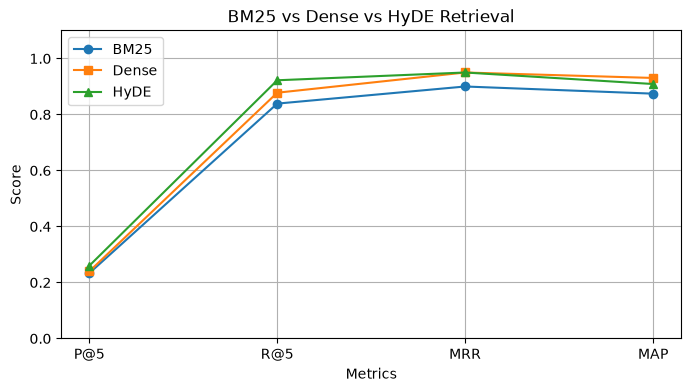

In [18]:
import matplotlib.pyplot as plt

metrics = ['P@5', 'R@5', 'MRR', 'MAP']
bm25_vals = [bm25_metrics['P@k'], bm25_metrics['R@k'], bm25_metrics['MRR'], bm25_metrics['MAP']]
dense_vals = [dense_metrics['P@k'], dense_metrics['R@k'], dense_metrics['MRR'], dense_metrics['MAP']]
hyde_vals = [hyde_metrics['P@k'], hyde_metrics['R@k'], hyde_metrics['MRR'], hyde_metrics['MAP']]

x = range(len(metrics))

plt.figure(figsize=(8,4))
plt.plot(x, bm25_vals, marker='o', label='BM25')
plt.plot(x,dense_vals, marker='s', label='Dense')
plt.plot(x,hyde_vals, marker='^', label='HyDE')
plt.xticks(x,metrics) # x축 눈금은 0~3 지표명
plt.ylim(0,1.1)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('BM25 vs Dense vs HyDE Retrieval')
plt.legend()
plt.grid()
plt.show()

##### HyDE의 역할과 효과
- HyDE는 쿼리를 “의미가 풍부한 가상문서”로 확장
- Dense가 이미 강력한 경우:
    - 성능을 보완하거나 유지
    - 항상 큰 폭의 개선을 보장하지는 않음
- 하지만 쿼리가 짧거나 모호한 경우, HyDE의 효과는 더욱 커질 가능성 있음

- Dense Retrieval은 의미 기반 검색의 기본 선택지
- HyDE는 다음 상황에서 특히 유용:
    - 짧고 추상적인 쿼리
    - 질문형 질의
    - Recall 개선이 중요한 경우
- 실서비스에서는: Dense + (HyDE / BM25 / Rerank) 조합이 가장 현실적인 접근